# تسک هفتگی شماره ۱

## Data Understanding بر اساس فرآیند CRISP-DM

### سناریوی کسب‌وکار

شما به عنوان تحلیلگر داده در یک مرکز درمانی قلب و عروق استخدام شده‌اید.

مدیریت مرکز قصد دارد یک سیستم هوشمند غربالگری اولیه برای تشخیص ریسک بیماری قلبی طراحی کند تا بیماران پرخطر قبل از انجام آزمایش‌های گران‌قیمت شناسایی شوند.

قبل از هرگونه مدل‌سازی، تیم داده باید شناخت کاملی از داده‌ها به دست آورد:

- چه نوع بیمارانی در دیتاست حضور دارند؟
- چه ویژگی‌هایی احتمالاً با بیماری قلبی مرتبط هستند؟
- توزیع بیماران چگونه است؟
- آیا داده متعادل است؟
- آیا الگوهای خاصی در گروه‌های مختلف بیماران وجود دارد؟
- آیا کیفیت داده برای مدل‌سازی مناسب است؟

مدیریت از شما خواسته است تنها با استفاده از مرحله Data Understanding گزارش اولیه‌ای از وضعیت داده‌ها تهیه کنید.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## دیتاست

Heart Disease UCI

### لینک گیت‌هاب:

url = https://github.com/trojrobert/Classification-of-heart-disease-uci-data-/blob/master/heart.csv?utm_source=chatgpt.com

### اطلاعات کلی دیتاست:

حدود 300 رکورد
14 ویژگی
هدف: تشخیص وجود یا عدم وجود بیماری قلبی

### ویژگی هدف:

target

- 0 → بدون بیماری قلبی

- 1 → دارای بیماری قلبی

این دیتاست یکی از مشهورترین دیتاست‌های حوزه سلامت است و بارها در تحقیقات پزشکی و داده‌کاوی استفاده شده است.

---



In [2]:
df = pd.read_csv("/home/sadra/Desktop/Data-Mining-task/task_1/heart.csv")

# خروجی مورد انتظار

دانشجو باید یک Notebook تحویل دهد که شامل:

کد هر سوال
خروجی کد
تحلیل شخصی از خروجی

برای هر سوال حداقل ۳ تا ۵ خط تحلیل نوشته شود.

صرفاً گذاشتن نمودار یا جدول بدون تحلیل نمره ندارد.

---

# قوانین

- استفاده از Scikit-Learn ممنوع

- انجام Data Cleaning ممنوع

- حذف داده ممنوع

- Feature Engineering ممنوع

### فقط از پکیج های زیر استفاده شود:

1. NumPy

2. Pandas

3. Matplotlib

4. Seaborn

---

# بخش اول: شناخت اولیه دیتاست

### سوال 1
چند سطر و چند ستون در دیتاست وجود دارد؟

ابزار پیشنهادی:

- shape

In [3]:
df.shape


(303, 14)

### Analysis of Question 1:

۳۰۳ رکورد
۱۴ ستون


---

### سوال 2

نام تمام ستون‌ها چیست؟

ابزار پیشنهادی: columns

In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

### Analysis of Question 2:

age سن

sex جنسیت

cp نوع درد قفسه سینه 

trestbps فشار خون استراحت

chol کلسترول

fbs  قند خون ناشتا

restecg نوار قلب

thalach حداکثر ضربان قلب

exang آنژین ناشی از ورزش

oldpeak stافت موج 

slope شیب قطعه اس تی در ورزش

ca تعداد عروق اصلی

thal تالاسمی

target متغییر هدف


---

### سوال 3

نوع داده هر ستون چیست؟

ابزار پیشنهادی: dtypes , info()

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### Analysis of Question 3

    age       int64  
    sex       int64  
    cp        int64  
    trestbps  int64  
    chol      int64  
    fbs       int64  
    restecg   int64  
    thalach   int64  
    exang     int64  
    oldpeak   float64
    slope     int64  
    ca        int64  
    thal      int64  
    target    int64 

---

### سوال 4

برای هر ستون تعیین کنید:

- عددی
- دسته‌ای
- دودویی

In [256]:
for index in df.columns:
    number_unique = df[index].nunique()
    types = None
    if number_unique == 2:
        types = "boolian"
    elif 6 > number_unique > 2:
        types = "categorical"
    else:
        types = "numerical"
    print(f"{index}: {number_unique} -> {types}")


age: 41 -> numerical
sex: 2 -> boolian
cp: 4 -> categorical
trestbps: 49 -> numerical
chol: 152 -> numerical
fbs: 2 -> boolian
restecg: 3 -> categorical
thalach: 91 -> numerical
exang: 2 -> boolian
oldpeak: 40 -> numerical
slope: 3 -> categorical
ca: 5 -> categorical
thal: 4 -> categorical
target: 2 -> boolian


### Analysis of Question 4

age: عددی

sex: دسته ای

cp: دسته ای

trestbps: عددی

chol: عددی

fbs: دودویی

restecg: دسته ای 

thalach: عددی

exang: دودویی

oldpeak: عددی

slope: دسته ای

ca: دسته ای

thal: دسته ای

 target:  دودویی



---

### سوال 5

از دید کسب‌وکار، هر ستون چه مفهومی دارد؟

(جدول توضیحات تهیه شود.)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### Analysis of Question 5


ویژگی|ترجمه|نوع
|---|---|---|
|age | سن|عددی
|sex |جنسیت|دسته ای
|cp |نوع درد قفسه سینه |دسته ای
|trestbps |فشار خون استراحت|عددی
|chol |کلسترول|عددی
|fbs | قند خون ناشتا|دودویی
|restecg |نوار قلب|دسته ای
|thalach |حداکثر ضربان قلب|عددی
|exang |آنژین ناشی از ورزش|دودویی
|oldpeak |stافت موج |عددی
|slope |شیب قطعه اس تی در ورزش|دسته ای
|ca |تعداد عروق اصلی|دودویی
|thal |تالاسمی|دسته ای
|target |متغییر هدف |دودویی 


---

# بخش دوم: کیفیت داده

### سوال 6

در هر ستون چند مقدار Null وجود دارد؟

In [33]:
for index in df.columns:
    print(f"{index} -> {df[index].isna().sum()}")

age -> 0
sex -> 0
cp -> 0
trestbps -> 0
chol -> 0
fbs -> 0
restecg -> 0
thalach -> 0
exang -> 0
oldpeak -> 0
slope -> 0
ca -> 0
thal -> 0
target -> 0


### Analysis of Question 6

هیچ مقدار خالی وجود ندارد


---

### سوال 7

درصد داده‌های گمشده هر ستون چقدر است؟

In [35]:
for index in df.columns:
    missing_value = (df[index] == "").sum() + df[index].isna().sum()
    print(f"{index} -> {missing_value} null")

age -> 0 null
sex -> 0 null
cp -> 0 null
trestbps -> 0 null
chol -> 0 null
fbs -> 0 null
restecg -> 0 null
thalach -> 0 null
exang -> 0 null
oldpeak -> 0 null
slope -> 0 null
ca -> 0 null
thal -> 0 null
target -> 0 null


### Analysis of Question 7

هیچ ستونی مقدار گمشده ندارد

___

### سوال 8

آیا رکورد تکراری وجود دارد؟

In [10]:
df.loc[df.duplicated(keep = False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


### Analysis of Question 8

ردیف ۱۶۴ تکرار ردیف ۱۶۳ هست


---

### سوال 9

اگر رکورد تکراری وجود دارد:

- چند عدد است؟
- چند درصد کل داده است؟

In [40]:
duplicate = df.duplicated().sum()
duplicate_percent = (duplicate / len(df) *100).round(2)
print(f"{duplicate_percent}%")

0.33%


### Analysis of Question 9

یک داده تکراری است و تقریبا ۳ صدم درصد داده ها میشه


---

# بخش سوم: شناخت متغیر هدف

### سوال 10

توزیع کلاس‌های target چگونه است؟

ابزار:
- value_counts
- countplot
- pie chart

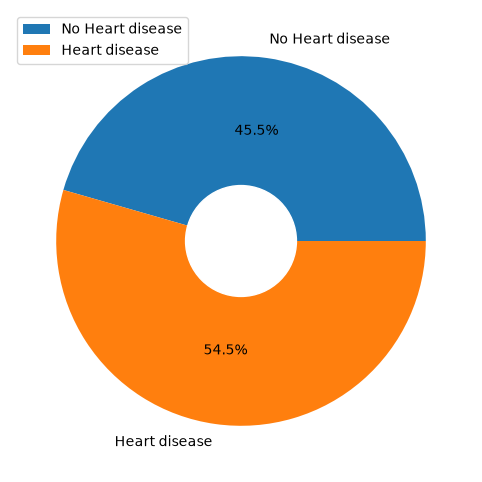

/tmp/ipykernel_76355/3247587501.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["woman","men"])


[Text(0, 0, 'woman'), Text(1, 0, 'men')]

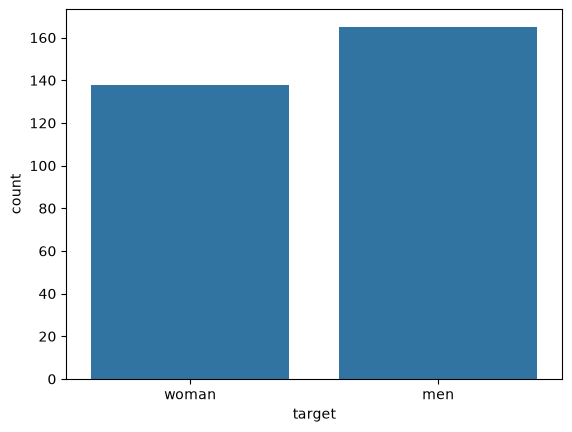

In [265]:
target = df["target"].value_counts().sort_index()
label = []

for index in target.index:
    if index == 0:
        index = "No Heart disease"
        label.append(index)
    else:
        index = "Heart disease"
        label.append(index)
plt.figure(figsize =(12,6))   
plt.pie(target,labels = label,autopct='%1.1f%%' , startangle = 0)
plt.legend(loc = "upper left")
circle = plt.Circle((0,0),0.3,color="white")
plt.gca().add_artist(circle)
plt.show()
ax = sns.countplot(x="target",data = df)
ax.set_xticklabels(["woman","men"])



### Analysis of Question 10

 ۴۵.۵٪ بیمار هستن 
 ۵۴.۵٪ سالم هستن
 


---

### سوال 11

آیا دیتاست متعادل است؟

با عدد و نمودار توضیح دهید.

In [107]:
target = df["target"].value_counts().sort_index()
ratio = target.min() / target.max().round(2)

if ratio > 0.8:
    b = ("balance")
elif 0.8 > ratio > 0.4:
    b = ("middle")
else:
    b = ("unbalance")    
print(f"{ratio} -> {b}")




0.8363636363636363 -> balance


### Analysis of Question 11

برای متعادل بودن باید ستون تارگت رو بررسی کنیم و اگر بالای ۰.۸ باشه متعادل است


---

# بخش چهارم: تحلیل ویژگی‌های عددی

ویژگی‌های عددی را استخراج کنید.

### سوال 12

برای تمام ویژگی‌های عددی آمار توصیفی کامل استخراج کنید.

ابزار:
- describe()

In [13]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Analysis of Question 12

در جدول بالا تمامی مقادیر مشخص شده وجود دارد


---

### سوال 13

برای هر ویژگی عددی:

- میانگین
- میانه
- مد

را محاسبه کنید.

In [28]:
col = df.select_dtypes(exclude = "object").columns
dict = {}
for index in df[col]:
    dict[index] = {
    "median" : df[index].median(),
    "mean" :df[index].mean(),
    "mode" : df[index].mode()[0]
    }
df2 = pd.DataFrame(dict).T
df2

,median,mean,mode
age,55.0,54.366337,58.0
sex,1.0,0.683168,1.0
cp,1.0,0.966997,0.0
trestbps,130.0,131.623762,120.0
chol,240.0,246.264026,197.0
fbs,0.0,0.148515,0.0
restecg,1.0,0.528053,1.0
thalach,153.0,149.646865,162.0
exang,0.0,0.326733,0.0
oldpeak,0.8,1.039604,0.0


### Analysis of Question 13

در جدول بالا وجود دارد


---

### سوال 14

برای هر ویژگی عددی:

- واریانس
- انحراف معیار

را محاسبه کنید.

In [29]:
col = df.select_dtypes(exclude = "object").columns
dict = {}
for index in df[col]:
    dict[index] = {
    "std" : df[index].std(),
    "var" :df[index].var(),
    }
df2 = pd.DataFrame(dict).T
df2

,std,var
age,9.082101,82.484558
sex,0.466011,0.217166
cp,1.032052,1.065132
trestbps,17.538143,307.586453
chol,51.830751,2686.426748
fbs,0.356198,0.126877
restecg,0.525860,0.276528
thalach,22.905161,524.646406
exang,0.469794,0.220707
oldpeak,1.161075,1.348095


### Analysis of Question 14

در جدول بالا وجود دارد


---

### سوال 15

برای هر ویژگی عددی هیستوگرام رسم کنید.

تحلیل:

- شکل توزیع
- چولگی احتمالی

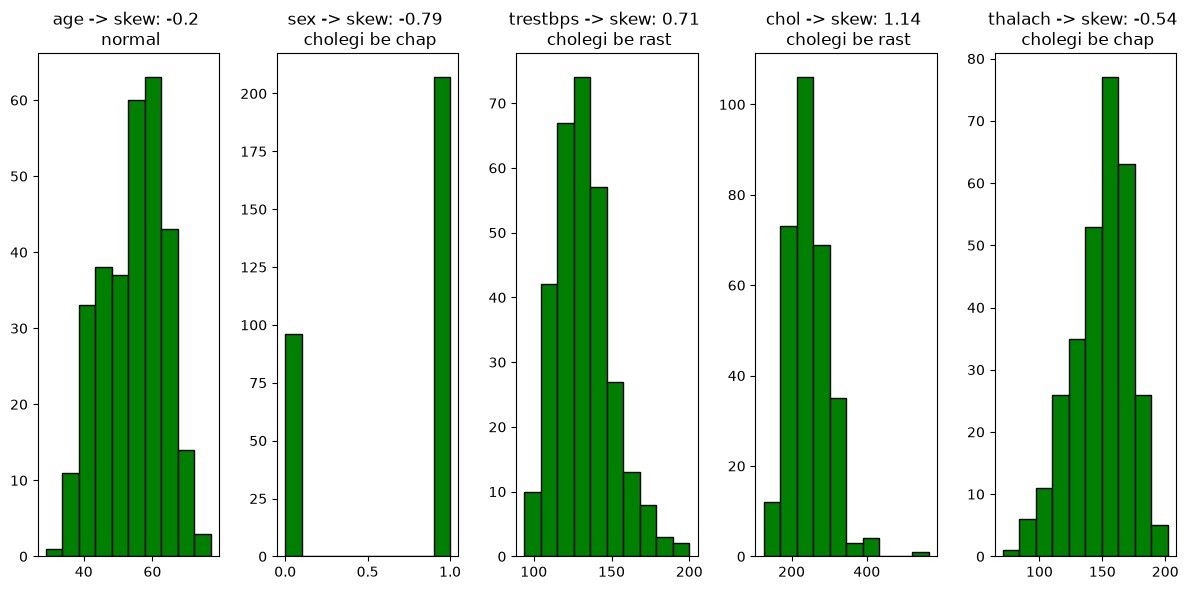

In [266]:
lst = [df["age"] ,df["sex"] ,df["trestbps"], df["chol"], df["thalach"]]
fig , ax = plt.subplots(nrows = 1 , ncols = 5 , figsize=(12,6))
for index , col in enumerate(lst):
    ax[index].hist(col,color="green",edgecolor="black")
    cholegi = col.skew().round(2)
    if cholegi > 0.5:
        a ="cholegi be rast"
    elif cholegi < -0.5:
        a = "cholegi be chap"
    else:
        a = "normal"
    ax[index].set_title(f"{col.name} -> skew: {cholegi} \n {a}")
plt.tight_layout()
plt.show()



### Analysis of Question 15

در جدول بالا وجود دارد


---

### سوال 16

برای تمام ویژگی‌های عددی Boxplot رسم کنید.

تحلیل:

- وجود یا عدم وجود Outlier

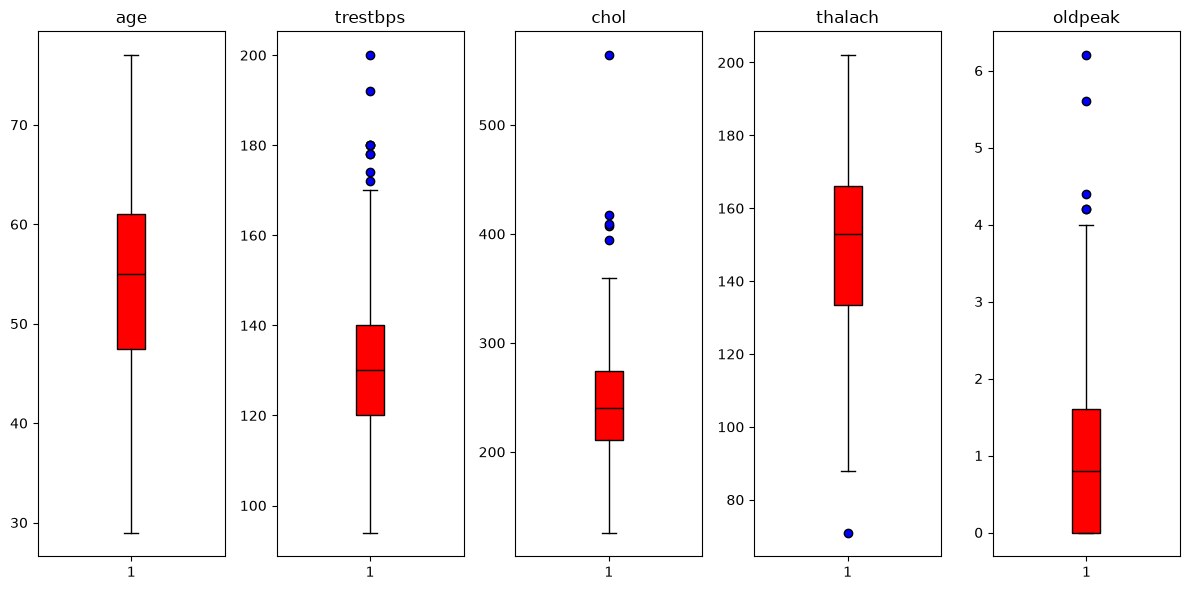

In [273]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique > 6:
        col.append(index)
fig , ax = plt.subplots(figsize=(12,6),ncols=len(col))
for i ,column in enumerate(col):
    ax[i].boxplot(df[column],patch_artist=True,boxprops={"facecolor":"red"},medianprops={"color":"black"},flierprops={"markerfacecolor":"blue"})
    ax[i].set_title(column)
plt.tight_layout()


### Analysis of Question 16

طبق نمودار های بالا فقط سن داده پرت ندارد


---

### سوال 17

برای تمام ویژگی‌های عددی KDE Plot رسم کنید.

تحلیل:

- نرمال بودن یا نبودن توزیع

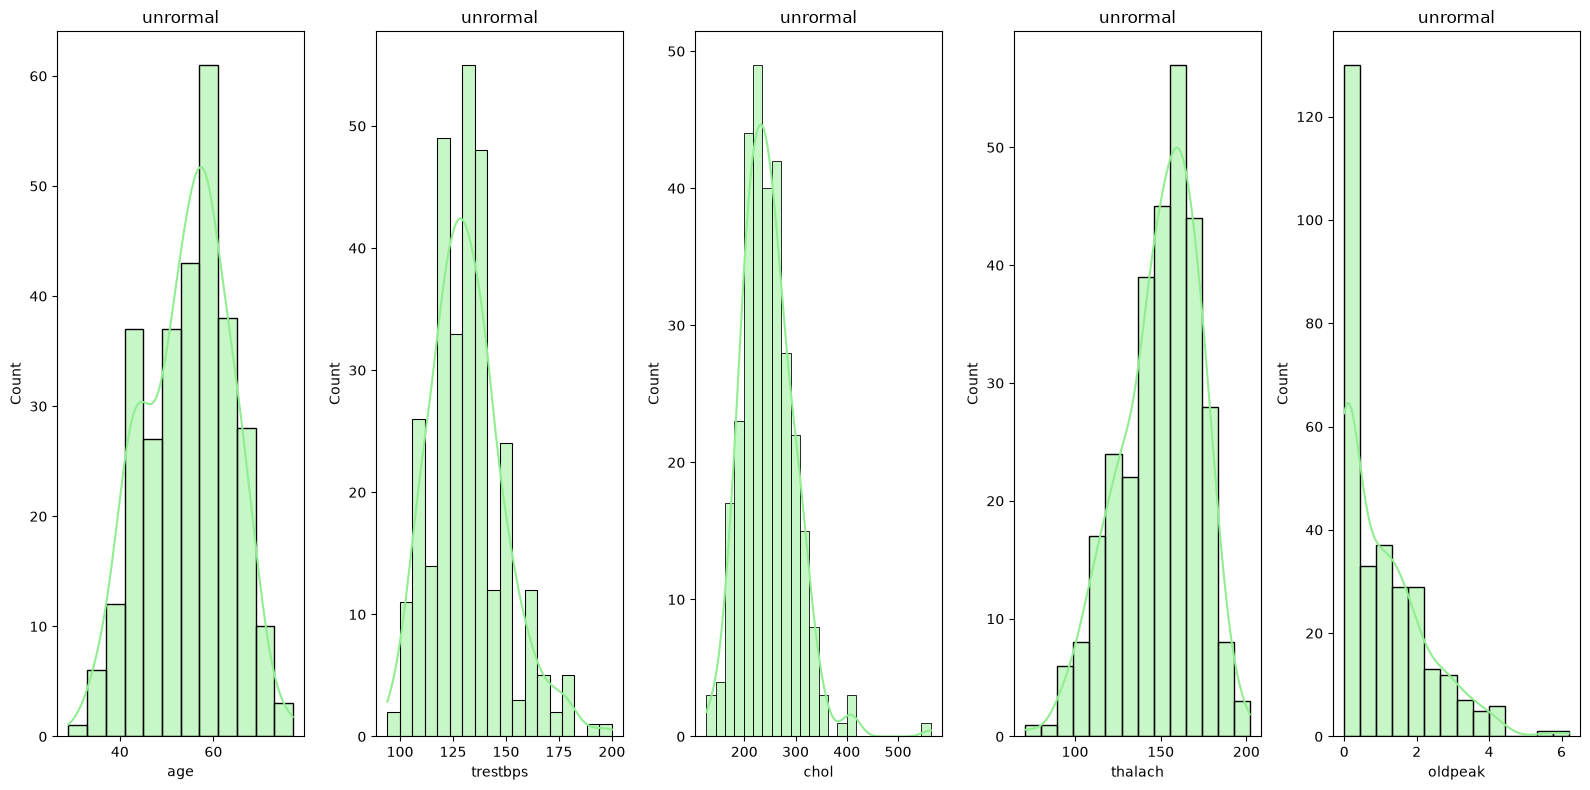

In [281]:
col = []
skew = df[column].skew().round(2)
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique > 6:
        col.append(index)
fig , ax = plt.subplots(figsize=(16,8),ncols=5)
for index , column in enumerate(col):
    sns.histplot(df[column],kde= True,ax = ax[index],color="lightgreen")
    ax[index].set_title(f"{"normal" if -0.5 < skew < 0.5 else "unrormal"}")
plt.tight_layout()
plt.show()


### Analysis of Question 17

هیچ کدوم نرمال نیست


---

# بخش پنجم: تحلیل ویژگی‌های دسته‌ای

### سوال 18

برای تمام ویژگی‌های دسته‌ای:

فراوانی هر دسته را محاسبه کنید.

In [157]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if 6 > number_unique > 2:
        col.append(index)
for index , column in enumerate(col):
    v_count = df[column].value_counts()
    print(v_count)
    


cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64
restecg
1    152
0    147
2      4
Name: count, dtype: int64
slope
2    142
1    140
0     21
Name: count, dtype: int64
ca
0    175
1     65
2     38
3     20
4      5
Name: count, dtype: int64
thal
2    166
3    117
1     18
0      2
Name: count, dtype: int64


### Analysis of Question 18

### cp

0    143

2     87

1     50

3     23


### restecg

1    152

0    147

2      4

### slope

2    142

1    140

0     21

### ca

0    175

1     65

2     38

3     20

4      5

### thal

2    166

3    117

1     18

0      2



---

### سوال 19

برای تمام ویژگی‌های دسته‌ای Countplot رسم کنید.

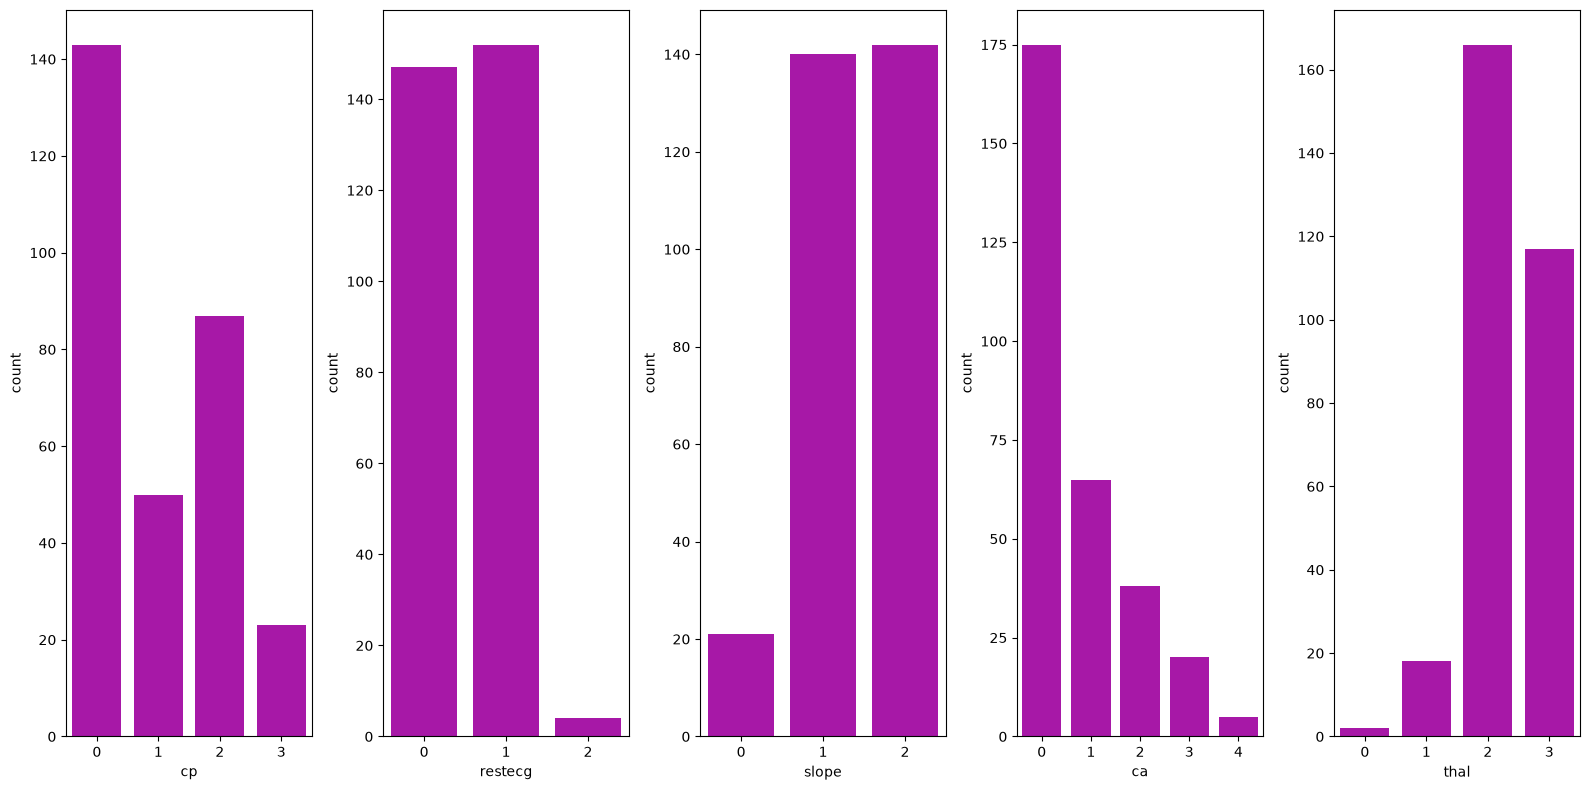

In [283]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if 6 > number_unique > 2:
        col.append(index)
fig , ax = plt.subplots(figsize=(16,8),ncols=5)
for index , column in enumerate(col):
    sns.countplot(data= df , x=column,ax=ax[index],color="m")
plt.tight_layout()
plt.show()


---

### سوال 20

بررسی کنید آیا توزیع جنسیت (sex) متعادل است یا خیر؟

In [286]:
c = df["sex"].value_counts()
moteadel = c.min() / c.max()
if moteadel > 0.8:
    print("moteadel")
else:
    print("moteadel nist")



moteadel nist


### Analysis of Question 20

طبق نمودار بالا جنسیت متعادل نیست


---

# بخش ششم: ارتباط ویژگی‌ها با هدف

### سوال 21

برای تمام ویژگی‌های عددی:

توزیع آنها را بر اساس target مقایسه کنید.

ابزار:

- boxplot
- violinplot

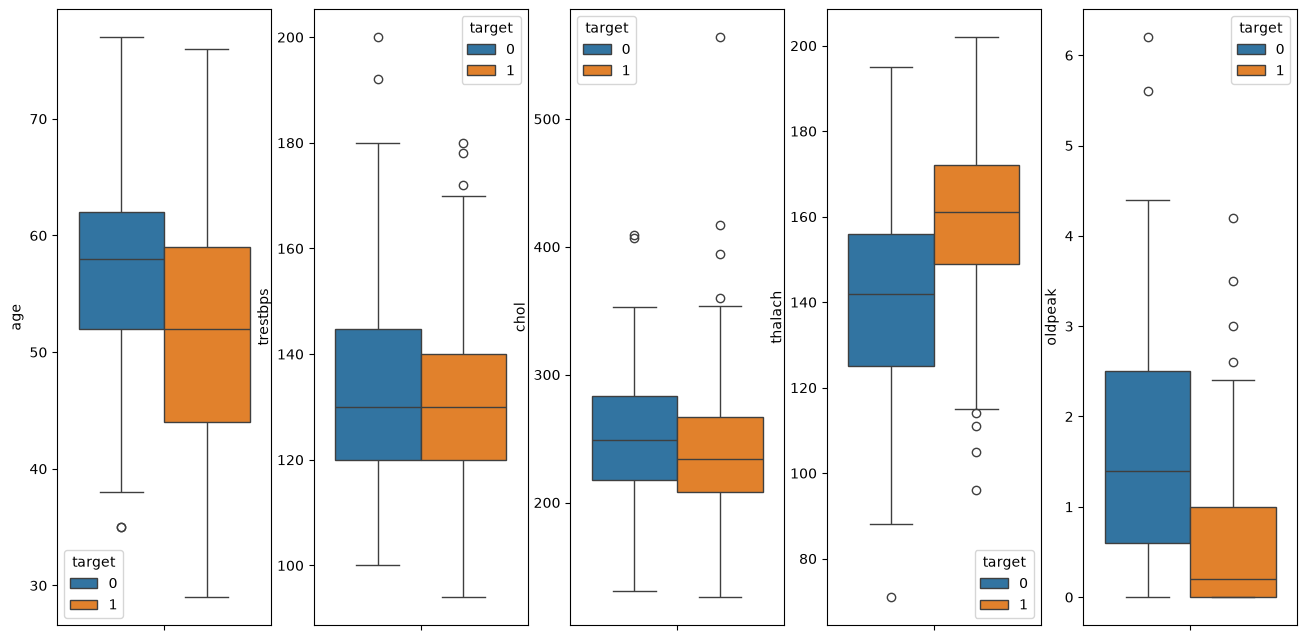

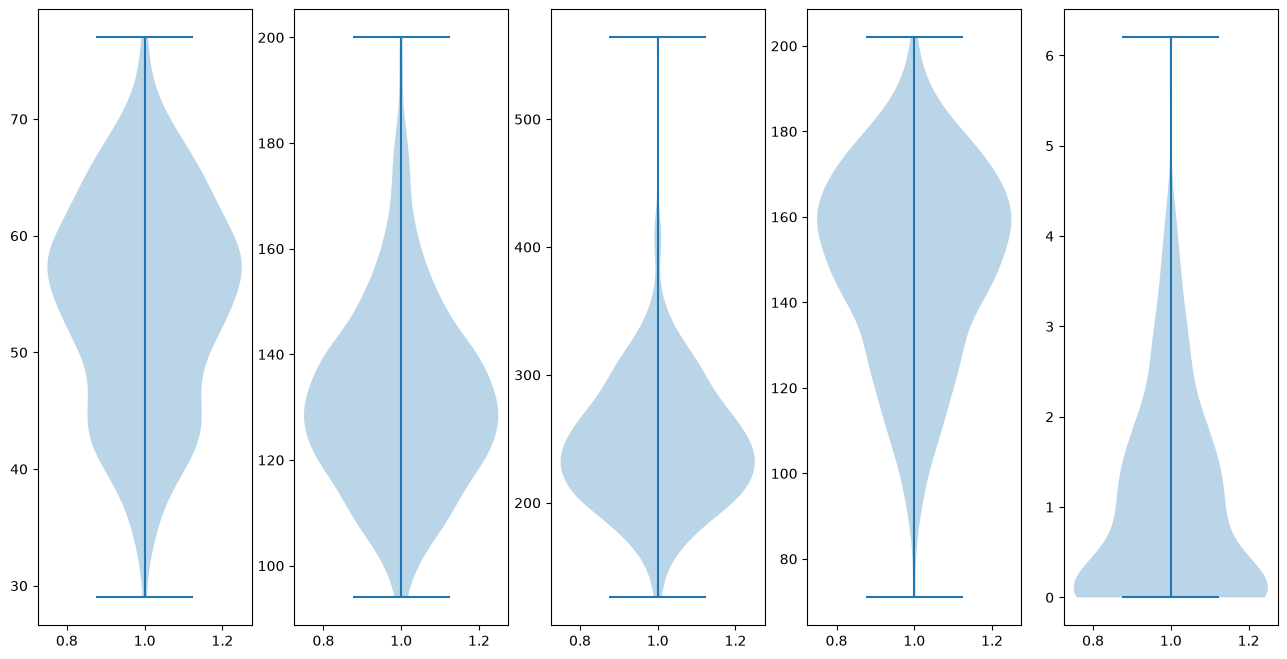

In [202]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique >  6:
        col.append(index)
fig,ax = plt.subplots(figsize=(16,8),ncols=5)
for i , column in enumerate(col):
    sns.boxplot(data = df,y = column,patch_artist=True,hue = df["target"],ax=ax[i])
plt.show()

fig_1,ax_1 = plt.subplots(figsize=(16,8),ncols=5)
for i , column in enumerate(col):
    ax_1[i].violinplot(df[column])
plt.show()





---

### سوال 22

برای ویژگی age بررسی کنید:

آیا افراد مسن‌تر بیشتر در کلاس بیماری قرار گرفته‌اند؟

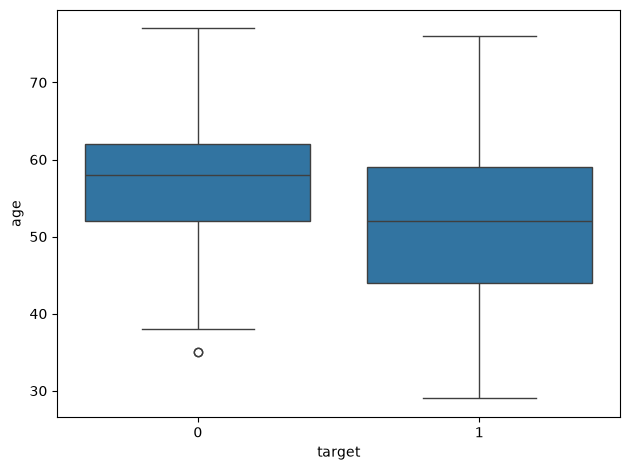

In [301]:
ax = sns.boxplot(df,y="age",x="target")
plt.tight_layout()
plt.show()



### Analysis of Question 22

 طبق نمودار بالا لزوما افراد مسن بیمار نیستن


---

### سوال 23

برای ویژگی chol بررسی کنید:

آیا بیماران دارای کلسترول بالاتر بیشتر بیمار هستند؟

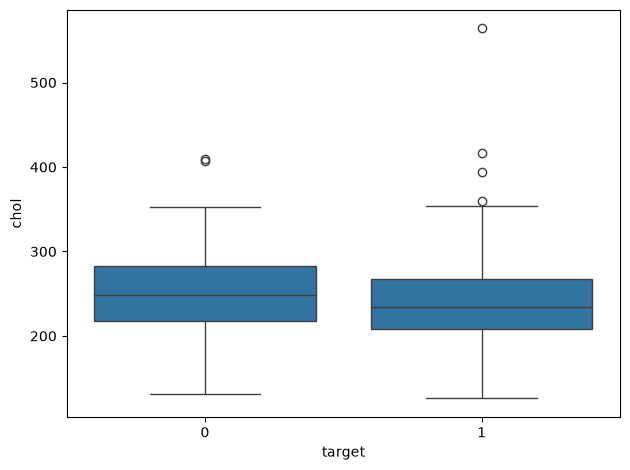

In [229]:
sns.boxplot(df,y="chol",x="target")
plt.tight_layout()
plt.show()

### Analysis of Question 22

 طبق نمودار بالا لزوما افراد دارای کلسترول بالاتر بیمار نیستن


---

### سوال 24

برای ویژگی thalach بررسی کنید:

حداکثر ضربان قلب در افراد بیمار و سالم چه تفاوتی دارد؟


---

### سوال 25

برای ویژگی oldpeak بررسی کنید:

رابطه آن با بیماری چیست؟


---

### سوال 26

برای تمام ویژگی‌های دسته‌ای:

Cross Tab با target ایجاد کنید.

ابزار:

- pd.crosstab()


---

### سوال 27

برای ویژگی sex:

احتمال بیماری در مردان و زنان را مقایسه کنید.


---

### سوال 28

برای ویژگی cp (نوع درد قفسه سینه):

کدام دسته بیشترین ارتباط را با بیماری دارد؟


---

### سوال 29

برای ویژگی exang:

آیا ورزش‌محور بودن درد با بیماری ارتباط دارد؟


---

# بخش هفتم: تحلیل روابط بین ویژگی‌ها

### سوال 30

ماتریس همبستگی را محاسبه کنید.

ابزار:

- corr()

In [231]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696



---

### سوال 31

Heatmap همبستگی رسم کنید.

ابزار:

- sns.heatmap()

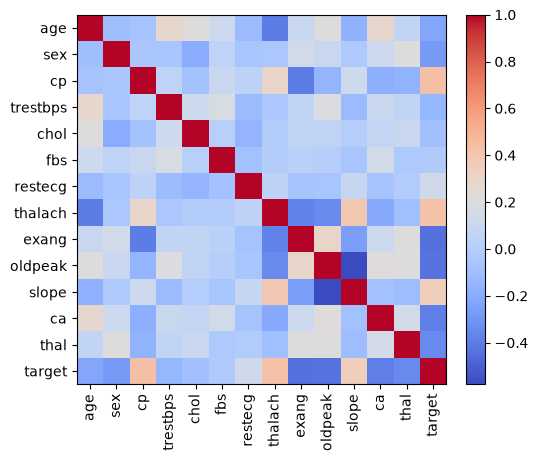

In [255]:
corr_matrix =df.corr()
fig ,ax = plt.subplots()
img = ax.imshow(corr_matrix,cmap="coolwarm")
cbar = fig.colorbar(img,ax=ax,fraction = 0.05 , pad = 0.04)
ax.set_xticks(np.arange(len(df.columns)))
ax.set_yticks(np.arange(len(df.columns)))
ax.set_xticklabels(df.columns,rotation = 90)
ax.set_yticklabels(df.columns);


---

### سوال 32

بیشترین همبستگی مثبت با target مربوط به کدام ویژگی است؟

In [246]:
corr = df.corr()
corr["target"].sort_values(ascending=False)

target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64

### Analysis of Question 33

مربوط به cp


---

### سوال 33

بیشترین همبستگی منفی با target مربوط به کدام ویژگی است؟

### Analysis of Question 33

مربوط به exang


---

### سوال 34

سه جفت ویژگی با بالاترین همبستگی را پیدا کنید.

### Analysis of Question 33

cp          
thalach     
slope 


---

### سوال 35

Scatter Plot بین موارد زیر رسم کنید:

- age و chol
- age و thalach
- chol و trestbps

و رنگ را بر اساس target تعیین کنید.


---

### سوال 36

Pairplot برای مهم‌ترین ویژگی‌ها رسم کنید.

ابزار:

- sns.pairplot()


---

# بخش هشتم: تحلیل چندمتغیره

### سوال 37

میانگین تمام ویژگی‌های عددی را برای دو کلاس target مقایسه کنید.

In [254]:
col = []
for index in df.columns:
    number_unique = df[index].nunique()
    if number_unique > 6:
        col.append(index)
df.groupby("target")[col].mean().unstack()

          target
age       0          56.601449
          1          52.496970
trestbps  0         134.398551
          1         129.303030
chol      0         251.086957
          1         242.230303
thalach   0         139.101449
          1         158.466667
oldpeak   0           1.585507
          1           0.583030
dtype: float64


---

### سوال 38

گروه‌بندی بر اساس sex و target انجام دهید و میانگین ویژگی‌ها را مقایسه کنید.

ابزار:

- groupby()

In [253]:
df.groupby(by=["target","sex"]).mean().unstack()

age                   cp              trestbps              \
sex             0          1         0         1           0           1   
target                                                                     
0       59.041667  56.087719  0.166667  0.543860  146.125000  131.929825   
1       54.555556  50.903226  1.333333  1.408602  128.736111  129.741935   

              chol                   fbs            ...     exang           \
sex              0           1         0         1  ...         0        1   
target                                              ...                      
0       274.958333  246.061404  0.250000  0.140351  ...  0.583333  0.54386   
1       256.750000  230.989247  0.083333  0.182796  ...  0.111111  0.16129   

         oldpeak               slope                  ca           thal  \
sex            0         1         0         1         0         1    0   
target                                                                    
0       1.841667  1.531579  0.958333  1.210526  1.291667  1.140351  2.5   
1       0.554167  0.605376  1.583333  1.602151  0.305556  0.408602  2.0   

                  
sex            1  
target            
0       2.552632  
1       2.215054  

[2 rows x 24 columns]


---

### سوال 39

گروه‌بندی بر اساس cp و target انجام دهید.

In [252]:
df.groupby(by=["target","cp"]).size().unstack()

cp,0,1,2,3
target,,,,
0,104,9,18,7
1,39,41,69,16



---

### سوال 40

سه پروفایل مختلف از بیماران استخراج کنید:

مثال:

- بیمار پرریسک
- بیمار کم‌ریسک
- بیمار مرزی

(فقط بر اساس مشاهده داده‌ها)


---

# گزارش نهایی (مهم‌ترین بخش پروژه)

در پایان دانشجو باید به این ۵ سوال مدیریتی پاسخ دهد:

1. مهم‌ترین ویژگی‌هایی که احتمالاً با بیماری قلبی ارتباط دارند کدام‌اند؟
2. کدام ویژگی‌ها برای مدل‌سازی آینده احتمالاً ارزش بیشتری دارند؟
3. چه مشکلاتی در داده مشاهده شد؟ (فقط شناسایی، نه رفع)
4. اگر مدیر بیمارستان فقط اجازه استفاده از ۵ ویژگی را بدهد، شما کدام ۵ ویژگی را پیشنهاد می‌کنید و چرا؟
5. آیا این دیتاست برای ورود به مرحله Data Preparation مناسب به نظر می‌رسد؟ چرا؟

---

# هدف آموزشی پنهان این تمرین

اگر دانشجو همه ۴۰ سوال را انجام دهد، عملاً با:

- Pandas Profiling ذهنی
- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis
- Distribution Analysis
- Correlation Analysis
- Business Understanding Validation

آشنا می‌شود و بدون اینکه حتی یک مدل بسازد، می‌تواند مانند یک Data Analyst حرفه‌ای درباره دیتاست صحبت کند. این دقیقاً خروجی مطلوب مرحله Data Understanding در CRISP-DM است.